# Walls → IFC JSON

**Bridge between WallSegmentation + WallImageProcessing → json_to_ifc4**

Re-segments room point clouds to recover 3D wall geometry, reads detected
openings from WallImageProcessing output, merges wall faces into physical
walls, deduplicates shared walls across rooms, and writes a JSON file
ready for `json_to_ifc4.ipynb`.

**Pipeline:**

1. Load each room's point cloud and re-segment walls to recover 3D positions.
2. Compute wall centerline endpoints (start/end), height, and thickness.
3. Merge parallel close-offset wall segments (two faces of the same wall → one physical wall).
4. Read door/window detections from WallImageProcessing and attach them to their host walls.
5. Deduplicate shared walls across adjacent rooms.
6. Export the canonical JSON for `json_to_ifc4.ipynb`.

## 0 · Environment setup

In [16]:
!pip install -q open3d scipy

### Mount Google Drive (if running on Colab)

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Imports

In [18]:
import os
import glob
import json
import math
from dataclasses import dataclass

import numpy as np
import open3d as o3d
from scipy.signal import find_peaks
from scipy.ndimage import uniform_filter1d

## 1 · Configuration

In [ ]:
@dataclass
class Config:
    # ---- input ----
    room_cloud_glob: str = '/content/drive/MyDrive/ONESTRUCTION/walls_only/*.ply'
    openings_dir: str = '/content/drive/MyDrive/ONESTRUCTION/wall_openings_out'

    # ---- wall segmentation (must match WallSegmentation settings) ----
    up_axis: int = 2
    voxel_m: float = 0.02
    normal_radius_m: float = 0.10
    normal_max_nn: int = 30
    normal_tol_deg: float = 15.0
    angle_tol_deg: float = 10.0
    offset_tol_m: float = 0.20
    min_wall_points: int = 200

    # ---- quality filters ----
    min_directions: int = 2               # skip rooms with fewer wall directions (diagonal artifacts)
    max_wall_length_m: float = 15.0       # reject walls longer than this (building-spanning artifacts)

    # ---- wall image resolution (must match WallSegmentation / WallImageProcessing) ----
    pixel_m: float = 0.04

    # ---- merge / dedup ----
    default_thickness: float = 0.15
    max_merge_thickness: float = 0.35
    dedup_offset_tol: float = 0.20
    dedup_overlap_frac: float = 0.30

    # ---- output ----
    project_name: str = 'Scanned Building'
    floor_elevation: float = 0.0
    output_path: str = '/content/drive/MyDrive/ONESTRUCTION/building.json'


CFG = Config()
print(f"Room clouds  : {CFG.room_cloud_glob}")
print(f"Openings dir : {CFG.openings_dir}")
print(f"Output       : {CFG.output_path}")
print(f"Wall seg     : tol={CFG.normal_tol_deg}°  offset={CFG.offset_tol_m}m  "
      f"min_pts={CFG.min_wall_points}")
print(f"Filters      : min_directions={CFG.min_directions}  "
      f"max_wall_length={CFG.max_wall_length_m}m")

## 2 · Definitions

### Wall segmentation (subset from WallSegmentation.ipynb)

Re-segments each room's point cloud to recover the 3D position of every
wall. Uses the same algorithm and parameters as `WallSegmentation.ipynb`
so that wall indices match the images that `WallImageProcessing` processed.

In [ ]:
def _cluster_1d_gaps(values, tol):
    """Split sorted values at gaps > tol."""
    if len(values) == 0:
        return np.array([], dtype=int)
    order = np.argsort(values)
    sorted_v = values[order]
    labels_sorted = np.zeros(len(sorted_v), dtype=int)
    label = 0
    for i in range(1, len(sorted_v)):
        if sorted_v[i] - sorted_v[i - 1] > tol:
            label += 1
        labels_sorted[i] = label
    result = np.empty(len(values), dtype=int)
    result[order] = labels_sorted
    return result


def _find_angle_peaks(theta, n_bins=180, smooth_width=5, min_height_frac=0.02):
    """Find dominant wall-direction peaks in the angle histogram.

    Handles 0°/180° wrap-around by running find_peaks on the full
    tripled histogram, then mapping peaks back to [0, π).
    """
    counts, edges = np.histogram(theta, bins=n_bins, range=(0, np.pi))
    centres = 0.5 * (edges[:-1] + edges[1:])

    tiled = np.concatenate([counts, counts, counts])
    smoothed_tiled = uniform_filter1d(tiled.astype(float), size=smooth_width)

    height_thr = smoothed_tiled[n_bins:2*n_bins].max() * min_height_frac
    min_dist = max(1, int(15 / (180 / n_bins)))

    all_peaks, _ = find_peaks(smoothed_tiled, height=height_thr, distance=min_dist)

    peak_bins = []
    for p in all_peaks:
        bin_idx = p % n_bins
        if bin_idx not in peak_bins:
            peak_bins.append(bin_idx)

    final_bins = []
    for b in peak_bins:
        merged = False
        for i, fb in enumerate(final_bins):
            circ_dist = min(abs(b - fb), n_bins - abs(b - fb))
            if circ_dist < min_dist:
                if smoothed_tiled[n_bins + b] > smoothed_tiled[n_bins + fb]:
                    final_bins[i] = b
                merged = True
                break
        if not merged:
            final_bins.append(b)

    if final_bins:
        return centres[np.array(final_bins, dtype=int)]
    return np.array([])


def _assign_to_nearest_peak(theta, peak_centres):
    """Assign each angle to the nearest peak (circular-aware)."""
    labels = np.empty(len(theta), dtype=int)
    for i, t in enumerate(theta):
        dists = np.minimum(np.abs(peak_centres - t),
                           np.pi - np.abs(peak_centres - t))
        labels[i] = np.argmin(dists)
    return labels


def segment_walls(pcd, cfg):
    """Segment a room point cloud into individual wall clusters.

    Returns (walls_list, n_directions). n_directions lets the caller
    skip rooms with only 1 wall direction (diagonal-line artifacts).
    """
    up_axis = cfg.up_axis
    if len(pcd.points) < cfg.min_wall_points:
        return [], 0

    pcd.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamHybrid(
            radius=cfg.normal_radius_m, max_nn=cfg.normal_max_nn))

    pts = np.asarray(pcd.points)
    norms = np.asarray(pcd.normals)

    up = np.zeros(3)
    up[up_axis] = 1.0
    cos_with_up = np.abs(norms @ up)
    sin_tol = np.sin(np.deg2rad(cfg.normal_tol_deg))
    vert_mask = cos_with_up < sin_tol

    pts_v = pts[vert_mask]
    norms_v = norms[vert_mask]
    if len(pts_v) < cfg.min_wall_points:
        return [], 0

    ha, hb = [a for a in range(3) if a != up_axis]
    nh = norms_v[:, [ha, hb]].copy()
    nh /= (np.linalg.norm(nh, axis=1, keepdims=True) + 1e-9)
    theta = np.arctan2(nh[:, 1], nh[:, 0]) % np.pi

    peak_centres = _find_angle_peaks(theta)
    n_directions = len(peak_centres)
    if n_directions == 0:
        return [], 0

    angle_labels = _assign_to_nearest_peak(theta, peak_centres)

    walls = []
    for a_label in range(n_directions):
        a_mask = angle_labels == a_label
        a_pts = pts_v[a_mask]
        a_nh = nh[a_mask]

        mean_n = a_nh.mean(axis=0)
        mean_n /= (np.linalg.norm(mean_n) + 1e-9)

        offsets = a_pts[:, ha] * mean_n[0] + a_pts[:, hb] * mean_n[1]
        off_labels = _cluster_1d_gaps(offsets, cfg.offset_tol_m)

        for o_label in np.unique(off_labels):
            o_mask = off_labels == o_label
            wall_pts = a_pts[o_mask]
            if len(wall_pts) < cfg.min_wall_points:
                continue

            cloud = o3d.geometry.PointCloud()
            cloud.points = o3d.utility.Vector3dVector(wall_pts)

            walls.append({
                'cloud': cloud,
                'normal_2d': mean_n.copy(),
                'offset': float(offsets[o_mask].mean()),
            })

    return walls, n_directions

### Geometry extraction

For each wall segment, compute the 2D centerline endpoints (`start`, `end`),
wall `height`, and estimated `thickness` from the point-cloud spread.

In [21]:
def compute_wall_geometry(wall, up_axis=2):
    """Compute 3D start/end, height, and thickness estimate for a wall."""
    pts = np.asarray(wall['cloud'].points)
    n2d = wall['normal_2d']

    ha, hb = [a for a in range(3) if a != up_axis]

    normal_3d = np.zeros(3)
    normal_3d[ha] = n2d[0]
    normal_3d[hb] = n2d[1]
    normal_3d /= (np.linalg.norm(normal_3d) + 1e-9)

    up = np.zeros(3)
    up[up_axis] = 1.0
    u_axis = np.cross(up, normal_3d)
    u_axis /= (np.linalg.norm(u_axis) + 1e-9)

    u = pts @ u_axis
    v = pts[:, up_axis]
    n_vals = pts[:, ha] * n2d[0] + pts[:, hb] * n2d[1]

    u_min, u_max = float(u.min()), float(u.max())
    v_min, v_max = float(v.min()), float(v.max())
    offset = wall['offset']

    thickness = float(np.percentile(n_vals, 95) - np.percentile(n_vals, 5))

    start_2d = [
        float(u_min * u_axis[0] + offset * normal_3d[0]),
        float(u_min * u_axis[1] + offset * normal_3d[1]),
    ]
    end_2d = [
        float(u_max * u_axis[0] + offset * normal_3d[0]),
        float(u_max * u_axis[1] + offset * normal_3d[1]),
    ]

    return {
        'start': start_2d,
        'end': end_2d,
        'height': v_max - v_min,
        'thickness': thickness,
        'floor_z': v_min,
        'length': u_max - u_min,
        'u_min': u_min,
        'u_max': u_max,
        'u_axis': u_axis.tolist(),
        'normal_3d': normal_3d.tolist(),
        'normal_2d': n2d.tolist(),
        'offset': offset,
        'angle': float(np.arctan2(n2d[1], n2d[0]) % np.pi),
    }

### Merge wall faces → physical walls

Two wall segments are faces of the same physical wall if they share the
same direction and their offsets differ by less than `max_merge_thickness`.
The merged wall gets the averaged centerline offset and the offset
difference becomes the wall thickness.

In [22]:
def _angle_close(a1, a2, tol_rad):
    diff = abs(a1 - a2)
    return min(diff, np.pi - diff) < tol_rad


def merge_wall_faces(wall_geos, cfg):
    """Merge parallel close-offset wall segments into single physical walls."""
    n = len(wall_geos)
    parent = list(range(n))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        a, b = find(a), find(b)
        if a != b:
            parent[b] = a

    angle_tol = np.deg2rad(cfg.angle_tol_deg)
    for i in range(n):
        for j in range(i + 1, n):
            if not _angle_close(wall_geos[i]['angle'], wall_geos[j]['angle'], angle_tol):
                continue
            offset_diff = abs(wall_geos[i]['offset'] - wall_geos[j]['offset'])
            if offset_diff > cfg.max_merge_thickness:
                continue
            u_overlap = (min(wall_geos[i]['u_max'], wall_geos[j]['u_max']) -
                         max(wall_geos[i]['u_min'], wall_geos[j]['u_min']))
            min_len = min(wall_geos[i]['length'], wall_geos[j]['length'])
            if min_len > 0 and u_overlap / min_len < 0.3:
                continue
            union(i, j)

    groups = {}
    for i in range(n):
        groups.setdefault(find(i), []).append(i)

    merged = []
    for indices in groups.values():
        if len(indices) == 1:
            g = wall_geos[indices[0]].copy()
            g['source_indices'] = indices
            if g['thickness'] < 0.05:
                g['thickness'] = cfg.default_thickness
            merged.append(g)
        else:
            geos = [wall_geos[i] for i in indices]
            avg_offset = np.mean([g['offset'] for g in geos])
            thickness = max(abs(g['offset'] - avg_offset) * 2 for g in geos)
            if thickness < 0.05:
                thickness = cfg.default_thickness

            u_min = min(g['u_min'] for g in geos)
            u_max = max(g['u_max'] for g in geos)
            height = max(g['height'] for g in geos)
            floor_z = min(g['floor_z'] for g in geos)

            ref = geos[0]
            u_axis = np.array(ref['u_axis'])
            normal_3d = np.array(ref['normal_3d'])

            start_2d = [
                float(u_min * u_axis[0] + avg_offset * normal_3d[0]),
                float(u_min * u_axis[1] + avg_offset * normal_3d[1]),
            ]
            end_2d = [
                float(u_max * u_axis[0] + avg_offset * normal_3d[0]),
                float(u_max * u_axis[1] + avg_offset * normal_3d[1]),
            ]

            merged.append({
                'start': start_2d,
                'end': end_2d,
                'height': height,
                'thickness': thickness,
                'floor_z': floor_z,
                'length': u_max - u_min,
                'u_min': u_min,
                'u_max': u_max,
                'u_axis': ref['u_axis'],
                'normal_3d': ref['normal_3d'],
                'normal_2d': ref['normal_2d'],
                'offset': float(avg_offset),
                'angle': ref['angle'],
                'source_indices': indices,
            })

    return merged

### Cross-room deduplication

Two walls from different rooms are the same physical wall if they share
the same direction, similar offset, and overlapping horizontal extent.
The longer wall is kept and openings from both sides are combined.

In [23]:
def _opening_duplicate(op, existing, pos_tol=0.15, size_tol=0.15):
    for e in existing:
        if e['label'] != op['label']:
            continue
        if (abs(e['offset'] - op['offset']) < pos_tol and
                abs(e['width'] - op['width']) < size_tol and
                abs(e['height'] - op['height']) < size_tol):
            return True
    return False


def deduplicate_walls(all_room_walls, cfg):
    """Remove duplicate walls that appear in multiple rooms."""
    flat = []
    for room_name, walls in all_room_walls.items():
        for i, w in enumerate(walls):
            flat.append({**w, '_room': room_name, '_idx': i,
                         '_openings': w.get('_openings', [])})

    n = len(flat)
    parent = list(range(n))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        a, b = find(a), find(b)
        if a != b:
            if flat[a]['length'] >= flat[b]['length']:
                parent[b] = a
            else:
                parent[a] = b

    angle_tol = np.deg2rad(cfg.angle_tol_deg)
    for i in range(n):
        for j in range(i + 1, n):
            if flat[i]['_room'] == flat[j]['_room']:
                continue
            if not _angle_close(flat[i]['angle'], flat[j]['angle'], angle_tol):
                continue
            if abs(flat[i]['offset'] - flat[j]['offset']) > cfg.dedup_offset_tol:
                continue
            u_overlap = (min(flat[i]['u_max'], flat[j]['u_max']) -
                         max(flat[i]['u_min'], flat[j]['u_min']))
            min_len = min(flat[i]['length'], flat[j]['length'])
            if min_len <= 0 or u_overlap / min_len < cfg.dedup_overlap_frac:
                continue
            union(i, j)

    groups = {}
    for i in range(n):
        groups.setdefault(find(i), []).append(i)

    unique_walls = []
    for root_idx, indices in groups.items():
        keeper = flat[root_idx].copy()
        all_openings = list(keeper.get('_openings', []))
        keeper_u_min = keeper['u_min']

        for idx in indices:
            if idx == root_idx:
                continue
            other = flat[idx]
            other_openings = other.get('_openings', [])
            normals_opposed = np.dot(keeper['normal_2d'], other['normal_2d']) < 0
            for op in other_openings:
                remapped = op.copy()
                if normals_opposed:
                    remapped['offset'] = keeper['length'] - op['offset'] - op['width']
                else:
                    u_shift = other['u_min'] - keeper_u_min
                    remapped['offset'] = op['offset'] + u_shift
                if not _opening_duplicate(remapped, all_openings):
                    all_openings.append(remapped)

        keeper['_openings'] = all_openings
        keeper.pop('_room', None)
        keeper.pop('_idx', None)
        unique_walls.append(keeper)

    return unique_walls

### Load openings from WallImageProcessing output

In [24]:
def load_openings(openings_dir):
    """Load per-room openings.json files from WallImageProcessing output.

    Handles both the new format (with pixel_m header) and the old flat
    list format.
    """
    rooms = {}
    pixel_m = 0.04

    all_path = os.path.join(openings_dir, 'all_openings.json')
    if os.path.exists(all_path):
        with open(all_path) as f:
            data = json.load(f)
        if isinstance(data, dict) and 'rooms' in data:
            pixel_m = data.get('pixel_m', 0.04)
            raw_rooms = data['rooms']
        elif isinstance(data, dict):
            raw_rooms = data
        else:
            raw_rooms = {}

        for room_name, walls_data in raw_rooms.items():
            rooms[room_name] = walls_data if isinstance(walls_data, list) else []
        return rooms, pixel_m

    room_dirs = sorted(glob.glob(os.path.join(openings_dir, 'room_*')))
    for rd in room_dirs:
        jp = os.path.join(rd, 'openings.json')
        if not os.path.exists(jp):
            continue
        room_name = os.path.basename(rd)
        with open(jp) as f:
            data = json.load(f)
        if isinstance(data, dict) and 'walls' in data:
            pixel_m = data.get('pixel_m', pixel_m)
            rooms[room_name] = data['walls']
        elif isinstance(data, list):
            rooms[room_name] = data
    return rooms, pixel_m

### Map openings onto merged walls

In [25]:
def attach_openings(merged_walls, source_wall_count, room_openings, pixel_m):
    """Attach openings from WallImageProcessing to their host walls.

    source_indices on each merged wall maps back to the original
    segmentation indices (wall_01 = index 0, wall_02 = index 1, etc).
    """
    for mw in merged_walls:
        mw['_openings'] = []

    wall_name_to_index = {}
    for entry in room_openings:
        name = entry.get('wall', '')
        idx = int(name.replace('wall_', '')) - 1 if name.startswith('wall_') else -1
        wall_name_to_index[name] = idx

    seg_idx_to_merged = {}
    for mi, mw in enumerate(merged_walls):
        for si in mw.get('source_indices', []):
            seg_idx_to_merged[si] = mi

    for entry in room_openings:
        wall_name = entry.get('wall', '')
        seg_idx = wall_name_to_index.get(wall_name, -1)
        merged_idx = seg_idx_to_merged.get(seg_idx)
        if merged_idx is None:
            continue

        for op in entry.get('openings', []):
            if op['label'] not in ('door', 'window'):
                continue

            offset_m = op.get('offset_m')
            if offset_m is None:
                offset_m = op['bbox_px'][0] * pixel_m

            opening = {
                'label': op['label'],
                'offset': round(offset_m, 3),
                'width': op['width_m'],
                'height': op['height_m'],
                'sill_height': op.get('sill_m', 0.0),
            }
            merged_walls[merged_idx]['_openings'].append(opening)

### Room boundaries (convex hull of wall endpoints)

In [26]:
def _convex_hull_2d(points):
    """Simple 2D convex hull (Graham scan)."""
    pts = points[np.lexsort((points[:, 1], points[:, 0]))]
    pts = np.unique(pts, axis=0)
    if len(pts) < 3:
        return pts.tolist()

    def cross(o, a, b):
        return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])

    lower = []
    for p in pts:
        while len(lower) >= 2 and cross(lower[-2], lower[-1], p) <= 0:
            lower.pop()
        lower.append(p.tolist())
    upper = []
    for p in reversed(pts):
        while len(upper) >= 2 and cross(upper[-2], upper[-1], p) <= 0:
            upper.pop()
        upper.append(p.tolist())

    return lower[:-1] + upper[:-1]


def compute_room_boundaries(all_room_walls):
    """Approximate room boundaries from wall endpoints."""
    boundaries = {}
    for room_name, walls in all_room_walls.items():
        pts = []
        for w in walls:
            pts.append(w['start'])
            pts.append(w['end'])
        if len(pts) < 3:
            boundaries[room_name] = []
            continue
        pts_arr = np.array(pts)
        boundaries[room_name] = _convex_hull_2d(pts_arr)
    return boundaries

## 3 · Run the pipeline

### 3.1 Discover room point clouds

In [27]:
room_cloud_paths = sorted(glob.glob(CFG.room_cloud_glob))
print(f"Found {len(room_cloud_paths)} room point clouds:")
for p in room_cloud_paths:
    print(f"  {os.path.basename(p)}")

assert len(room_cloud_paths) > 0, (
    f"No files matched {CFG.room_cloud_glob!r} — check the path in Config")

Found 66 room point clouds:
  room_01_walls.ply
  room_02_walls.ply
  room_03_walls.ply
  room_04_walls.ply
  room_05_walls.ply
  room_06_walls.ply
  room_07_walls.ply
  room_08_walls.ply
  room_09_walls.ply
  room_10_walls.ply
  room_11_walls.ply
  room_12_walls.ply
  room_13_walls.ply
  room_14_walls.ply
  room_15_walls.ply
  room_16_walls.ply
  room_17_walls.ply
  room_18_walls.ply
  room_19_walls.ply
  room_20_walls.ply
  room_21_walls.ply
  room_22_walls.ply
  room_23_walls.ply
  room_24_walls.ply
  room_25_walls.ply
  room_26_walls.ply
  room_27_walls.ply
  room_28_walls.ply
  room_29_walls.ply
  room_30_walls.ply
  room_31_walls.ply
  room_32_walls.ply
  room_33_walls.ply
  room_34_walls.ply
  room_35_walls.ply
  room_36_walls.ply
  room_37_walls.ply
  room_38_walls.ply
  room_39_walls.ply
  room_40_walls.ply
  room_41_walls.ply
  room_42_walls.ply
  room_43_walls.ply
  room_44_walls.ply
  room_45_walls.ply
  room_46_walls.ply
  room_47_walls.ply
  room_48_walls.ply
  room_49_wa

### 3.2 Load openings from WallImageProcessing

In [28]:
room_openings_all, pixel_m = {}, CFG.pixel_m
if os.path.isdir(CFG.openings_dir):
    room_openings_all, pixel_m = load_openings(CFG.openings_dir)
    print(f"Loaded openings for {len(room_openings_all)} rooms (pixel_m={pixel_m})")
    for rn, walls in sorted(room_openings_all.items()):
        n_op = sum(len(w.get('openings', [])) for w in walls)
        print(f"  {rn}: {len(walls)} walls, {n_op} openings")
else:
    print(f"Openings dir not found: {CFG.openings_dir}")
    print("Walls will be created without doors/windows.")

Loaded openings for 66 rooms (pixel_m=0.04)
  room_01: 15 walls, 12 openings
  room_02: 8 walls, 9 openings
  room_03: 17 walls, 12 openings
  room_04: 8 walls, 5 openings
  room_05: 6 walls, 7 openings
  room_06: 7 walls, 11 openings
  room_07: 8 walls, 8 openings
  room_08: 9 walls, 14 openings
  room_09: 6 walls, 8 openings
  room_10: 7 walls, 8 openings
  room_11: 7 walls, 5 openings
  room_12: 7 walls, 5 openings
  room_13: 9 walls, 14 openings
  room_14: 8 walls, 9 openings
  room_15: 8 walls, 6 openings
  room_16: 7 walls, 7 openings
  room_17: 6 walls, 5 openings
  room_18: 7 walls, 11 openings
  room_19: 14 walls, 13 openings
  room_20: 13 walls, 13 openings
  room_21: 15 walls, 13 openings
  room_22: 14 walls, 16 openings
  room_23: 13 walls, 14 openings
  room_24: 9 walls, 7 openings
  room_25: 10 walls, 7 openings
  room_26: 12 walls, 10 openings
  room_27: 16 walls, 13 openings
  room_28: 8 walls, 4 openings
  room_29: 6 walls, 4 openings
  room_30: 4 walls, 4 openings
  r

### 3.3 Segment, merge, and attach openings per room

In [ ]:
all_room_walls = {}
skipped_rooms = []

for cloud_path in room_cloud_paths:
    fname = os.path.splitext(os.path.basename(cloud_path))[0]
    room_name = fname.replace('_walls', '')

    print(f"\n{'='*60}")
    print(f"  {room_name}  ({os.path.basename(cloud_path)})")
    print(f"{'='*60}")

    pcd = o3d.io.read_point_cloud(cloud_path)
    pts = np.asarray(pcd.points)
    print(f"  Loaded {len(pts):,} points")
    if CFG.voxel_m > 0:
        pcd = pcd.voxel_down_sample(CFG.voxel_m)
        print(f"  After voxel downsample: {len(pcd.points):,} points")

    walls, n_dirs = segment_walls(pcd, CFG)
    print(f"  Segmented {len(walls)} wall segments in {n_dirs} direction(s)")

    # skip rooms with too few wall directions (diagonal-line artifacts)
    if n_dirs < CFG.min_directions:
        print(f"  ⚠️  SKIPPED: only {n_dirs} direction(s) < min_directions={CFG.min_directions}")
        skipped_rooms.append(room_name)
        continue

    wall_geos = [compute_wall_geometry(w, CFG.up_axis) for w in walls]

    # filter out implausibly long walls (building-spanning artifacts)
    before = len(wall_geos)
    wall_geos = [g for g in wall_geos if g['length'] <= CFG.max_wall_length_m]
    if len(wall_geos) < before:
        print(f"  Filtered {before - len(wall_geos)} walls > {CFG.max_wall_length_m}m long")

    if not wall_geos:
        print(f"  ⚠️  SKIPPED: no walls survived filtering")
        skipped_rooms.append(room_name)
        continue

    merged = merge_wall_faces(wall_geos, CFG)
    print(f"  Merged into {len(merged)} physical walls")

    # find matching openings key
    openings_key = room_name
    if openings_key not in room_openings_all:
        parts = room_name.split('_')
        for k in room_openings_all:
            if any(p in k for p in parts):
                openings_key = k
                break

    room_openings = room_openings_all.get(openings_key, [])
    if room_openings:
        attach_openings(merged, len(walls), room_openings, pixel_m)
        n_doors = sum(len([o for o in w.get('_openings', []) if o['label'] == 'door'])
                      for w in merged)
        n_wins = sum(len([o for o in w.get('_openings', []) if o['label'] == 'window'])
                     for w in merged)
        print(f"  Attached {n_doors} doors, {n_wins} windows")
    else:
        print(f"  No openings data found for {openings_key}")

    all_room_walls[room_name] = merged

print(f"\n{'='*60}")
print(f"Processed {len(all_room_walls)} rooms, skipped {len(skipped_rooms)}")
if skipped_rooms:
    print(f"Skipped: {', '.join(skipped_rooms)}")

### 3.4 Deduplicate across rooms

In [30]:
print("Deduplicating walls across rooms …")
unique_walls = deduplicate_walls(all_room_walls, CFG)

total_room = sum(len(w) for w in all_room_walls.values())
print(f"  {total_room} room-level walls → {len(unique_walls)} unique physical walls")
print(f"  Removed {total_room - len(unique_walls)} duplicate(s)")

Deduplicating walls across rooms …
  156 room-level walls → 147 unique physical walls
  Removed 9 duplicate(s)


### 3.5 Build the JSON

In [31]:
storey_id = "L0"
data = {
    "project": {"name": CFG.project_name},
    "storeys": [{
        "id": storey_id,
        "name": "Ground Floor",
        "elevation": CFG.floor_elevation,
    }],
    "walls": [],
    "doors": [],
    "windows": [],
    "rooms": [],
}

door_counter = 0
window_counter = 0

for i, w in enumerate(unique_walls):
    wall_id = f"W{i + 1}"
    thickness = w['thickness']
    if thickness < 0.05:
        thickness = CFG.default_thickness

    data["walls"].append({
        "id": wall_id,
        "storey": storey_id,
        "start": [round(w['start'][0], 4), round(w['start'][1], 4)],
        "end": [round(w['end'][0], 4), round(w['end'][1], 4)],
        "height": round(w['height'], 3),
        "thickness": round(thickness, 3),
    })

    for op in w.get('_openings', []):
        if op['label'] == 'door':
            door_counter += 1
            data["doors"].append({
                "id": f"D{door_counter}",
                "wall": wall_id,
                "offset": round(op['offset'], 3),
                "width": round(op['width'], 3),
                "height": round(op['height'], 3),
            })
        elif op['label'] == 'window':
            window_counter += 1
            data["windows"].append({
                "id": f"Win{window_counter}",
                "wall": wall_id,
                "offset": round(op['offset'], 3),
                "width": round(op['width'], 3),
                "height": round(op['height'], 3),
                "sill_height": round(op.get('sill_height', 0.9), 3),
            })

# add room boundaries
room_boundaries = compute_room_boundaries(all_room_walls)
for room_name, boundary in room_boundaries.items():
    if not boundary:
        continue
    heights = [rw['height'] for rw in all_room_walls.get(room_name, [])]
    room_height = max(heights) if heights else 2.5

    data["rooms"].append({
        "id": room_name,
        "storey": storey_id,
        "name": room_name.replace('_', ' ').title(),
        "boundary": [[round(x, 4), round(y, 4)] for x, y in boundary],
        "height": round(room_height, 3),
    })

print(f"Walls:   {len(data['walls'])}")
print(f"Doors:   {len(data['doors'])}")
print(f"Windows: {len(data['windows'])}")
print(f"Rooms:   {len(data['rooms'])}")

Walls:   147
Doors:   24
Windows: 18
Rooms:   25


### 3.6 Preview the JSON

In [32]:
print(json.dumps(data, indent=2))

{
  "project": {
    "name": "Scanned Building"
  },
  "storeys": [
    {
      "id": "L0",
      "name": "Ground Floor",
      "elevation": 0.0
    }
  ],
  "walls": [
    {
      "id": "W1",
      "storey": "L0",
      "start": [
        -3.6817,
        46.0103
      ],
      "end": [
        -3.4582,
        46.0167
      ],
      "height": 2.999,
      "thickness": 0.15
    },
    {
      "id": "W2",
      "storey": "L0",
      "start": [
        -5.4201,
        45.4105
      ],
      "end": [
        -3.68,
        45.4601
      ],
      "height": 2.823,
      "thickness": 0.15
    },
    {
      "id": "W3",
      "storey": "L0",
      "start": [
        -5.3987,
        42.9999
      ],
      "end": [
        -3.8593,
        43.0438
      ],
      "height": 2.881,
      "thickness": 0.15
    },
    {
      "id": "W4",
      "storey": "L0",
      "start": [
        -5.4497,
        43.0125
      ],
      "end": [
        -5.3705,
        45.4831
      ],
      "height": 2.88,
 

### 3.7 Save & download

In [33]:
os.makedirs(os.path.dirname(CFG.output_path), exist_ok=True)
with open(CFG.output_path, 'w') as f:
    json.dump(data, f, indent=2)
print(f"Saved to {CFG.output_path}")

try:
    from google.colab import files
    files.download(CFG.output_path)
except Exception:
    pass

Saved to /content/drive/MyDrive/ONESTRUCTION/building.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 3.8 Top-down preview

Quick floor-plan sketch showing wall centerlines and opening positions
so you can sanity-check before feeding into `json_to_ifc4.ipynb`.

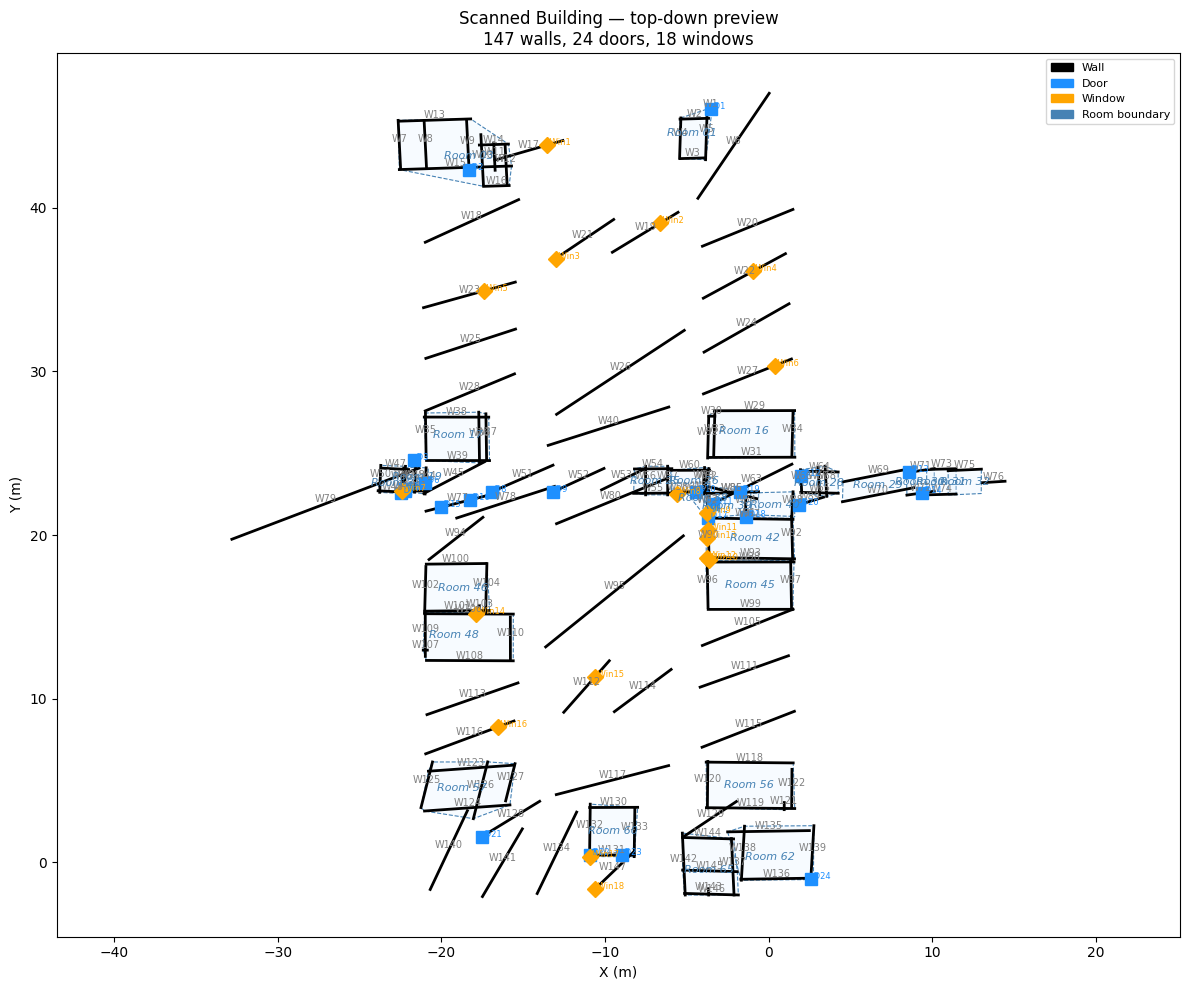

In [34]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 10))

for wall in data['walls']:
    sx, sy = wall['start']
    ex, ey = wall['end']
    ax.plot([sx, ex], [sy, ey], 'k-', linewidth=2)
    mx, my = (sx + ex) / 2, (sy + ey) / 2
    ax.text(mx, my, wall['id'], fontsize=7, ha='center', va='bottom',
            color='grey')

for door in data['doors']:
    wall = next(w for w in data['walls'] if w['id'] == door['wall'])
    sx, sy = wall['start']
    ex, ey = wall['end']
    length = math.hypot(ex - sx, ey - sy)
    if length == 0:
        continue
    ux, uy = (ex - sx) / length, (ey - sy) / length
    dx = sx + ux * door['offset']
    dy = sy + uy * door['offset']
    ax.plot(dx, dy, 's', color='dodgerblue', markersize=8)
    ax.text(dx, dy, f" {door['id']}", fontsize=6, color='dodgerblue')

for win in data['windows']:
    wall = next(w for w in data['walls'] if w['id'] == win['wall'])
    sx, sy = wall['start']
    ex, ey = wall['end']
    length = math.hypot(ex - sx, ey - sy)
    if length == 0:
        continue
    ux, uy = (ex - sx) / length, (ey - sy) / length
    wx = sx + ux * win['offset']
    wy = sy + uy * win['offset']
    ax.plot(wx, wy, 'D', color='orange', markersize=8)
    ax.text(wx, wy, f" {win['id']}", fontsize=6, color='orange')

for room in data['rooms']:
    bnd = room['boundary']
    if len(bnd) >= 3:
        poly = plt.Polygon(bnd, fill=True, facecolor=(0.9, 0.95, 1.0, 0.3),
                           edgecolor='steelblue', linewidth=0.8, linestyle='--')
        ax.add_patch(poly)
        cx = np.mean([p[0] for p in bnd])
        cy = np.mean([p[1] for p in bnd])
        ax.text(cx, cy, room['name'], fontsize=8, ha='center', va='center',
                color='steelblue', fontstyle='italic')

ax.set_aspect('equal', adjustable='datalim')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_title(f"{data['project']['name']} — top-down preview\n"
             f"{len(data['walls'])} walls, {len(data['doors'])} doors, "
             f"{len(data['windows'])} windows")
ax.legend(handles=[
    mpatches.Patch(color='black', label='Wall'),
    mpatches.Patch(color='dodgerblue', label='Door'),
    mpatches.Patch(color='orange', label='Window'),
    mpatches.Patch(color='steelblue', label='Room boundary'),
], fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()